
Bootstrap summary with MODE (pixel-level ε distributions)
Units: hr^-1
Reported: mode, median ± 95% CI, mean ± 95% CI

CORE
  ε_cwp  mode=8.459  median=8.358 [8.337, 8.379]  mean=10.014 [9.970, 10.059]  N=211561
  ε_ciw  mode=15.888  median=16.443 [16.390, 16.493]  mean=29.500 [27.478, 32.469]  N=211557
  ε_clw  mode=19.254  median=18.552 [18.499, 18.603]  mean=23.612 [23.392, 23.868]  N=211559

COLD_ANVIL
  ε_cwp  mode=3.227  median=3.238 [3.228, 3.246]  mean=6.113 [4.735, 8.732]  N=230282
  ε_ciw  mode=6.680  median=6.972 [6.945, 6.995]  mean=14.357 [13.779, 14.991]  N=230268
  ε_clw  mode=6.671  median=6.440 [6.420, 6.461]  mean=22.316 [18.671, 27.253]  N=229896

WARM_ANVIL
  ε_cwp  mode=2.068  median=1.994 [1.989, 1.999]  mean=3.057 [2.904, 3.260]  N=250335
  ε_ciw  mode=4.864  median=5.010 [4.995, 5.026]  mean=9.320 [8.843, 9.876]  N=250229
  ε_clw  mode=3.723  median=3.472 [3.461, 3.483]  mean=8.630 [8.049, 9.274]  N=250053

Saved stats CSV: /xdisk/sylvia/temakgoale/MCS_TRACKS_D

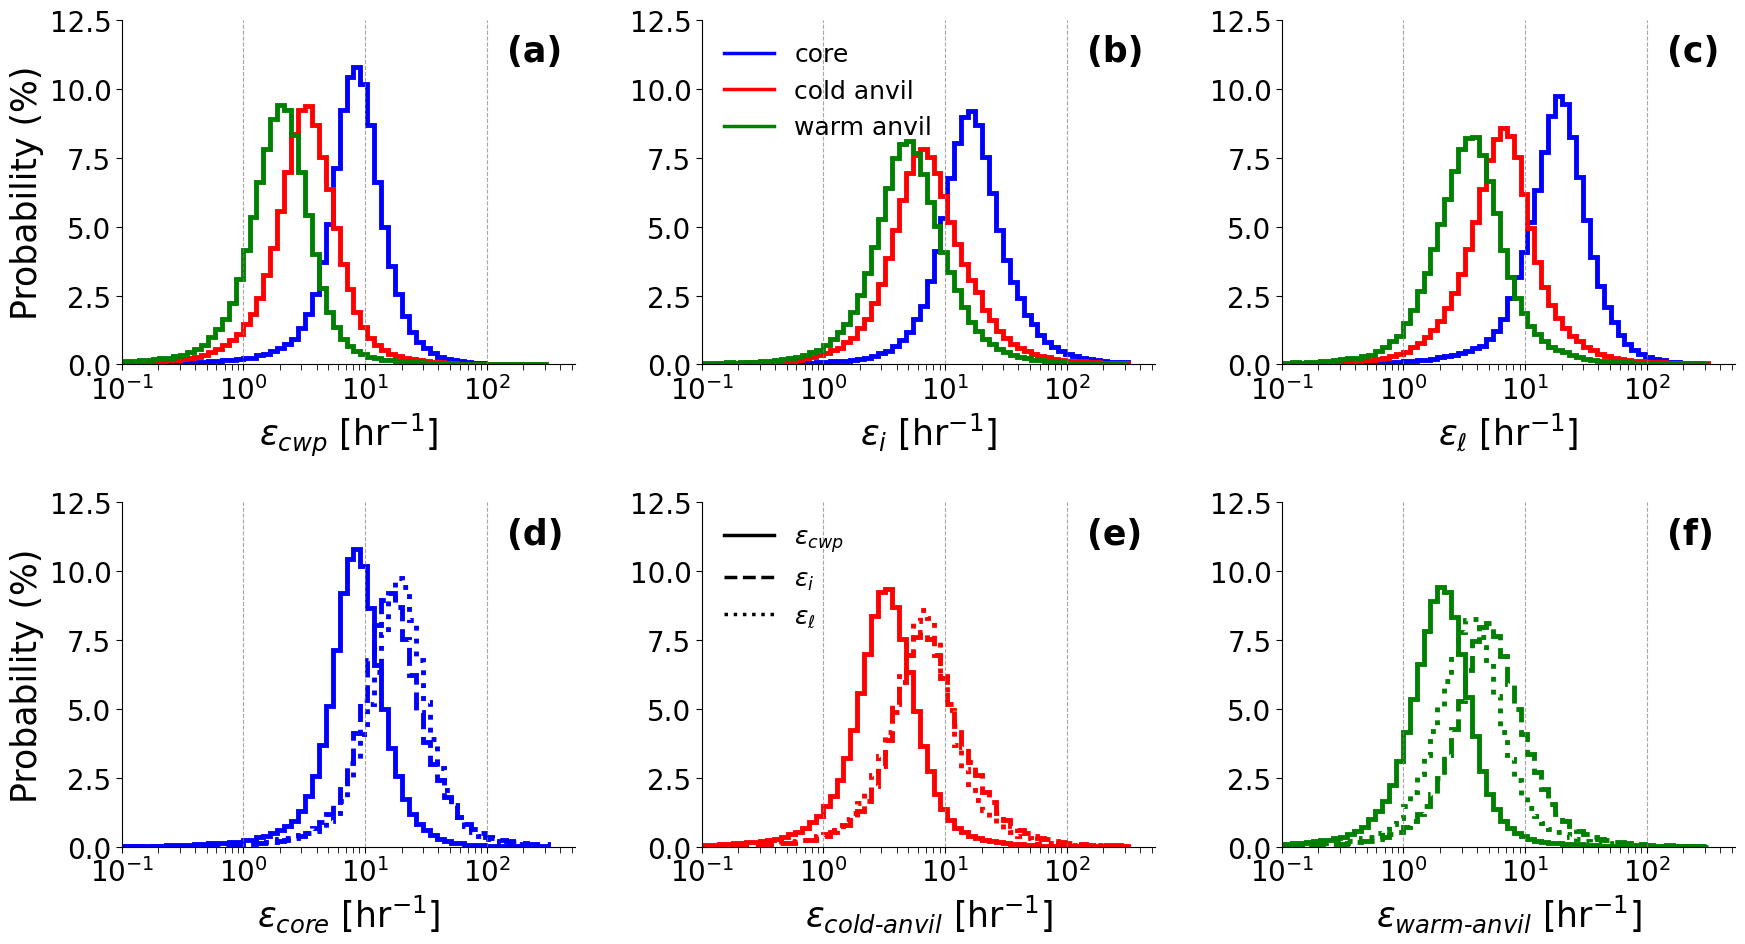

In [1]:
#!/usr/bin/env python3
"""
Pretty 2x3 histograms of PRECEFF for core / cold anvil / warm anvil,
with (cwp, ciw, clw) variants; log-scaled x-axis, percent-normalized y.

Updates in this version:
- Upper & right spines removed on every subplot
- Only two legends (top-middle and bottom-middle subplots)
- Auto-convert ε to hr^-1 (from s^-1) and update bins accordingly
- NEW: compute & print MODE (KDE mode in log10-space), plus 95% BOOTSTRAP CIs
       for median and mean for each region × metric
- NEW: optional: save a small CSV summary table alongside the figure

Author: Thabo Makgoale (edit as desired)
"""

import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

# ----------------------
# File paths
# ----------------------
basedir  = "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_PRECEFF/"
figdir   = "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/global/mcstracking/MCS_PRECEFF_PLOTS/"
os.makedirs(figdir, exist_ok=True)

# --- Whole region, MCS vs Non-MCS (not plotted here, kept for reference) ---
mcs_preff_cwp_fp = basedir + "Obs_cwp_PRECEFF_mcs_20160809-20160909_Asia_timeavg.nc"
mcs_preff_ciw_fp = basedir + "Obs_ciw_PRECEFF_mcs_20160809-20160909_Asia_timeavg.nc"
mcs_preff_clw_fp = basedir + "Obs_clw_PRECEFF_mcs_20160809-20160909_Asia_timeavg.nc"

non_mcs_preff_cwp_fp = basedir + "Obs_cwp_PRECEFF_non_mcs_20160809-20160909_Asia_timeavg.nc"
non_mcs_preff_ciw_fp = basedir + "Obs_ciw_PRECEFF_non_mcs_20160809-20160909_Asia_timeavg.nc"
non_mcs_preff_clw_fp = basedir + "Obs_clw_PRECEFF_non_mcs_20160809-20160909_Asia_timeavg.nc"

# --- Core / Anvil subsets (MCS only) ---
core_cwp_fp       = basedir + "Obs_cwp_PRECEFF_core_mcs_20160809-20160909_Asia_timeavg.nc"
cold_anvil_cwp_fp = basedir + "Obs_cwp_PRECEFF_cold_anvil_mcs_20160809-20160909_Asia_timeavg.nc"
warm_anvil_cwp_fp = basedir + "Obs_cwp_PRECEFF_warm_anvil_mcs_20160809-20160909_Asia_timeavg.nc"

core_ciw_fp       = basedir + "Obs_ciw_PRECEFF_core_mcs_20160809-20160909_Asia_timeavg.nc"
cold_anvil_ciw_fp = basedir + "Obs_ciw_PRECEFF_cold_anvil_mcs_20160809-20160909_Asia_timeavg.nc"
warm_anvil_ciw_fp = basedir + "Obs_ciw_PRECEFF_warm_anvil_mcs_20160809-20160909_Asia_timeavg.nc"

core_clw_fp       = basedir + "Obs_clw_PRECEFF_core_mcs_20160809-20160909_Asia_timeavg.nc"
cold_anvil_clw_fp = basedir + "Obs_clw_PRECEFF_cold_anvil_mcs_20160809-20160909_Asia_timeavg.nc"
warm_anvil_clw_fp = basedir + "Obs_clw_PRECEFF_warm_anvil_mcs_20160809-20160909_Asia_timeavg.nc"

# ----------------------
# Bootstrap settings
# ----------------------
N_BOOT    = 2000
CI_LEVEL  = 95
BOOT_SEED = 123

# ----------------------
# Unit handling (→ hr^-1)
# ----------------------
def scale_to_per_hour(da):
    """
    Returns values_1D_in_hr^-1.
    Scales ε to hr^-1 if the variable's units suggest s^-1.
    """
    units = (da.attrs.get("units") or "").strip().lower()
    vals = da.values.ravel()
    vals = vals[np.isfinite(vals)]

    if ("s-1" in units) or (units in {"1/s", "s^-1", "sec^-1", "per second"}):
        scale = 3600.0
    elif ("h-1" in units) or (units in {"1/h", "hr^-1", "hour^-1", "per hour"}):
        scale = 1.0
    else:
        # Heuristic if units missing/unknown
        m = np.nanmedian(vals) if vals.size else np.nan
        if np.isfinite(m) and (1e-6 <= m <= 1e-2):
            scale = 3600.0
        else:
            scale = 1.0

    return vals * scale

def open_var_flat_hr(fp, var="PRECEFF_TIMEAVG"):
    """Open dataset -> var -> scale to hr^-1 -> flatten finite values."""
    ds = xr.open_dataset(fp)
    try:
        da = ds[var]
        arr_hr = scale_to_per_hour(da)
    finally:
        ds.close()
    arr_hr = np.asarray(arr_hr)
    arr_hr = arr_hr[np.isfinite(arr_hr)]
    return arr_hr

# ----------------------
# Bootstrap CI helpers
# ----------------------
def bootstrap_ci(arr, stat_func=np.nanmedian, n_boot=2000, ci=95, seed=123):
    """
    Nonparametric bootstrap CI for a statistic (median by default).
    Returns (point_estimate, lo, hi).
    """
    arr = np.asarray(arr)
    arr = arr[np.isfinite(arr)]
    n = arr.size
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))   # (n_boot, n)
    samples = arr[idx]
    stats = stat_func(samples, axis=1)

    alpha = 100 - ci
    lo = np.nanpercentile(stats, alpha / 2.0)
    hi = np.nanpercentile(stats, 100 - alpha / 2.0)
    point = float(stat_func(arr))
    return float(point), float(lo), float(hi)

# ----------------------
# MODE helper (KDE mode in log10-space)
# ----------------------
def kde_mode_logspace(arr, n_grid=500):
    """
    Estimate mode of a positive, skewed distribution using Gaussian KDE
    in log10-space. Returns mode in linear units (hr^-1).
    """
    arr = np.asarray(arr)
    arr = arr[np.isfinite(arr) & (arr > 0)]
    if arr.size < 10:
        return np.nan

    logx = np.log10(arr)
    kde = gaussian_kde(logx)  # Scott's rule bandwidth by default
    xgrid = np.linspace(logx.min(), logx.max(), n_grid)
    log_mode = xgrid[np.argmax(kde(xgrid))]
    return float(10**log_mode)

def summarize_stats_bootstrap(arr, n_boot=2000, ci=95, seed=123):
    """
    Return mean, median, MODE, and bootstrap CI for mean and median, plus N.
    Units: hr^-1
    """
    arr = np.asarray(arr)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return {
            "mean": np.nan,
            "median": np.nan,
            "mode": np.nan,
            "N": 0,
            "mean_ci_lo": np.nan, "mean_ci_hi": np.nan,
            "median_ci_lo": np.nan, "median_ci_hi": np.nan,
        }

    mean = float(np.nanmean(arr))
    median = float(np.nanmedian(arr))
    mode = kde_mode_logspace(arr)

    _, mean_lo, mean_hi = bootstrap_ci(arr, stat_func=np.nanmean,
                                       n_boot=n_boot, ci=ci, seed=seed)
    _, med_lo, med_hi = bootstrap_ci(arr, stat_func=np.nanmedian,
                                     n_boot=n_boot, ci=ci, seed=seed + 1)

    return {
        "mean": mean,
        "median": median,
        "mode": mode,
        "N": int(arr.size),
        "mean_ci_lo": mean_lo, "mean_ci_hi": mean_hi,
        "median_ci_lo": med_lo, "median_ci_hi": med_hi,
    }

def print_stats_table(stats, ci=95):
    print("\n============================================================")
    print("Bootstrap summary with MODE (pixel-level ε distributions)")
    print("Units: hr^-1")
    print(f"Reported: mode, median ± {ci}% CI, mean ± {ci}% CI")
    print("============================================================\n")
    for region in ["core", "cold_anvil", "warm_anvil"]:
        print(region.upper())
        for metric in ["cwp", "ciw", "clw"]:
            s = stats[region][metric]
            print(
                f"  ε_{metric:<3}  "
                f"mode={s['mode']:.3f}  "
                f"median={s['median']:.3f} [{s['median_ci_lo']:.3f}, {s['median_ci_hi']:.3f}]  "
                f"mean={s['mean']:.3f} [{s['mean_ci_lo']:.3f}, {s['mean_ci_hi']:.3f}]  "
                f"N={s['N']}"
            )
        print()

def save_stats_csv(stats, out_csv):
    """Write a small CSV summary (no pandas dependency)."""
    lines = [(
        "region,metric,"
        "mode_hr-1,"
        "median_hr-1,median_ci_lo_hr-1,median_ci_hi_hr-1,"
        "mean_hr-1,mean_ci_lo_hr-1,mean_ci_hi_hr-1,N"
    )]
    for region in ["core", "cold_anvil", "warm_anvil"]:
        for metric in ["cwp", "ciw", "clw"]:
            s = stats[region][metric]
            lines.append(
                f"{region},{metric},"
                f"{s['mode']:.6f},"
                f"{s['median']:.6f},{s['median_ci_lo']:.6f},{s['median_ci_hi']:.6f},"
                f"{s['mean']:.6f},{s['mean_ci_lo']:.6f},{s['mean_ci_hi']:.6f},"
                f"{s['N']}"
            )
    with open(out_csv, "w") as f:
        f.write("\n".join(lines))
    print(f"Saved stats CSV: {out_csv}")

# ----------------------
# Y-axis formatting, styling helpers
# ----------------------
def format_yticks(ax, fontsize=30):
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=False))
    ax.ticklabel_format(style="plain", axis="y", scilimits=(0, 0))
    ax.tick_params(axis="y", which="both", labelsize=fontsize)
    ax.yaxis.get_offset_text().set_fontsize(fontsize)

def despine_upper_left(ax, move_y_to_right=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    if move_y_to_right:
        ax.yaxis.set_ticks_position("left")
        ax.yaxis.set_label_position("left")
    ax.tick_params(axis="both", which="both", length=4, direction="out")

def hist_pct(ax, data, bins, **kwargs):
    data = np.asarray(data)
    data = data[np.isfinite(data)]
    if data.size == 0:
        return
    weights = np.ones_like(data) * (100.0 / data.size)
    ax.hist(data, bins=bins, histtype="step", weights=weights, **kwargs)

def panel_label(ax, label_text, fontsize=25):
    ax.text(0.85, 0.88, label_text, transform=ax.transAxes,
            fontsize=fontsize, fontweight="bold")

# ----------------------
# Load data (scaled to hr^-1)
# ----------------------
core_cwp       = open_var_flat_hr(core_cwp_fp)
cold_anvil_cwp = open_var_flat_hr(cold_anvil_cwp_fp)
warm_anvil_cwp = open_var_flat_hr(warm_anvil_cwp_fp)

core_ciw       = open_var_flat_hr(core_ciw_fp)
cold_anvil_ciw = open_var_flat_hr(cold_anvil_ciw_fp)
warm_anvil_ciw = open_var_flat_hr(warm_anvil_ciw_fp)

core_clw       = open_var_flat_hr(core_clw_fp)
cold_anvil_clw = open_var_flat_hr(cold_anvil_clw_fp)
warm_anvil_clw = open_var_flat_hr(warm_anvil_clw_fp)

# ----------------------
# Compute & print MODE + bootstrap CI summaries
# ----------------------
stats = {
    "core": {
        "cwp": summarize_stats_bootstrap(core_cwp, n_boot=N_BOOT, ci=CI_LEVEL, seed=BOOT_SEED),
        "ciw": summarize_stats_bootstrap(core_ciw, n_boot=N_BOOT, ci=CI_LEVEL, seed=BOOT_SEED),
        "clw": summarize_stats_bootstrap(core_clw, n_boot=N_BOOT, ci=CI_LEVEL, seed=BOOT_SEED),
    },
    "cold_anvil": {
        "cwp": summarize_stats_bootstrap(cold_anvil_cwp, n_boot=N_BOOT, ci=CI_LEVEL, seed=BOOT_SEED),
        "ciw": summarize_stats_bootstrap(cold_anvil_ciw, n_boot=N_BOOT, ci=CI_LEVEL, seed=BOOT_SEED),
        "clw": summarize_stats_bootstrap(cold_anvil_clw, n_boot=N_BOOT, ci=CI_LEVEL, seed=BOOT_SEED),
    },
    "warm_anvil": {
        "cwp": summarize_stats_bootstrap(warm_anvil_cwp, n_boot=N_BOOT, ci=CI_LEVEL, seed=BOOT_SEED),
        "ciw": summarize_stats_bootstrap(warm_anvil_ciw, n_boot=N_BOOT, ci=CI_LEVEL, seed=BOOT_SEED),
        "clw": summarize_stats_bootstrap(warm_anvil_clw, n_boot=N_BOOT, ci=CI_LEVEL, seed=BOOT_SEED),
    },
}

print_stats_table(stats, ci=CI_LEVEL)

# Optional: save CSV summary
save_csv = True
if save_csv:
    out_csv = os.path.join(figdir, "MCS_region_metric_mode_bootstrapCI_hr-1.csv")
    save_stats_csv(stats, out_csv)

# ----------------------
# Plot styling & bins (define in hr^-1)
# ----------------------
plt.rcParams.update({
    "font.size": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

# Log-spaced bins in hr^-1 (tune range if needed)
bins = np.logspace(-2.0, 2.5, 80)

# Colors and line styles
core_color       = "blue"
cold_anvil_color = "red"
warm_anvil_color = "green"

cwp_ls = "solid"
ciw_ls = "dashed"
clw_ls = "dotted"

legend_handles_top = [
    Line2D([0], [0], color=core_color,       lw=2.5, ls="-", label="core"),
    Line2D([0], [0], color=cold_anvil_color, lw=2.5, ls="-", label="cold anvil"),
    Line2D([0], [0], color=warm_anvil_color, lw=2.5, ls="-", label="warm anvil"),
]
legend_handles_bottom = [
    Line2D([0], [0], color="black", lw=2.5, ls=cwp_ls, label=r"$\epsilon_{cwp}$"),
    Line2D([0], [0], color="black", lw=2.5, ls=ciw_ls, label=r"$\epsilon_{i}$"),
    Line2D([0], [0], color="black", lw=2.5, ls=clw_ls, label=r"$\epsilon_{\ell}$"),
]

# ----------------------
# Figure & axes
# ----------------------
fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharex=False, sharey=False)

# ========== TOP ROW ==========
# (a) epsilon_cwp by {core, cold anvil, warm anvil}
ax = axs[0, 0]
hist_pct(ax, core_cwp,       bins=bins, color=core_color,       linewidth=3.5)
hist_pct(ax, cold_anvil_cwp, bins=bins, color=cold_anvil_color, linewidth=3.5)
hist_pct(ax, warm_anvil_cwp, bins=bins, color=warm_anvil_color, linewidth=3.5)
ax.set_xscale("log")
ax.set_xlim(left=1e-1)
ax.set_ylabel("Probability (%)")
ax.set_xlabel(r"$\epsilon_{cwp}$ [hr$^{-1}$]")
panel_label(ax, "(a)")

# (b) epsilon_i by {core, cold anvil, warm anvil}
ax = axs[0, 1]
hist_pct(ax, core_ciw,       bins=bins, color=core_color,       linewidth=3.5)
hist_pct(ax, cold_anvil_ciw, bins=bins, color=cold_anvil_color, linewidth=3.5)
hist_pct(ax, warm_anvil_ciw, bins=bins, color=warm_anvil_color, linewidth=3.5)
ax.set_xscale("log")
ax.set_xlim(left=1e-1)
ax.set_xlabel(r"$\epsilon_{i}$ [hr$^{-1}$]")
panel_label(ax, "(b)")
ax.set_yticklabels([])

# (c) epsilon_l by {core, cold anvil, warm anvil}
ax = axs[0, 2]
hist_pct(ax, core_clw,       bins=bins, color=core_color,       linewidth=3.5)
hist_pct(ax, cold_anvil_clw, bins=bins, color=cold_anvil_color, linewidth=3.5)
hist_pct(ax, warm_anvil_clw, bins=bins, color=warm_anvil_color, linewidth=3.5)
ax.set_xscale("log")
ax.set_xlim(left=1e-1)
ax.set_xlabel(r"$\epsilon_{\ell}$ [hr$^{-1}$]")
panel_label(ax, "(c)")
ax.set_yticklabels([])

# ========== BOTTOM ROW ==========
# (d) core: overlay cwp, ciw, clw
ax = axs[1, 0]
hist_pct(ax, core_cwp, bins=bins, color=core_color, linewidth=3.5, linestyle=cwp_ls)
hist_pct(ax, core_ciw, bins=bins, color=core_color, linewidth=3.5, linestyle=ciw_ls)
hist_pct(ax, core_clw, bins=bins, color=core_color, linewidth=3.5, linestyle=clw_ls)
ax.set_xscale("log")
ax.set_xlim(left=1e-1)
ax.set_ylabel("Probability (%)")
ax.set_xlabel(r"$\epsilon_{core}$ [hr$^{-1}$]")
panel_label(ax, "(d)")

# (e) cold anvil: overlay cwp, ciw, clw
ax = axs[1, 1]
hist_pct(ax, cold_anvil_cwp, bins=bins, color=cold_anvil_color, linewidth=3.5, linestyle=cwp_ls)
hist_pct(ax, cold_anvil_ciw, bins=bins, color=cold_anvil_color, linewidth=3.5, linestyle=ciw_ls)
hist_pct(ax, cold_anvil_clw, bins=bins, color=cold_anvil_color, linewidth=3.5, linestyle=clw_ls)
ax.set_xscale("log")
ax.set_xlim(left=1e-1)
ax.set_xlabel(r"$\epsilon_{cold\text{-}anvil}$ [hr$^{-1}$]")
panel_label(ax, "(e)")
ax.set_yticklabels([])

# (f) warm anvil: overlay cwp, ciw, clw
ax = axs[1, 2]
hist_pct(ax, warm_anvil_cwp, bins=bins, color=warm_anvil_color, linewidth=3.5, linestyle=cwp_ls)
hist_pct(ax, warm_anvil_ciw, bins=bins, color=warm_anvil_color, linewidth=3.5, linestyle=ciw_ls)
hist_pct(ax, warm_anvil_clw, bins=bins, color=warm_anvil_color, linewidth=3.5, linestyle=clw_ls)
ax.set_xscale("log")
ax.set_xlim(left=1e-1)
ax.set_xlabel(r"$\epsilon_{warm\text{-}anvil}$ [hr$^{-1}$]")
panel_label(ax, "(f)")
ax.set_yticklabels([])

# ----------------------
# Axes formatting (sci y, despine)
# ----------------------
for ax in axs.ravel():
    format_yticks(ax, fontsize=20)
    despine_upper_left(ax, move_y_to_right=False)

# Common y-range
for ax in axs.ravel():
    ax.set_ylim(0, 12.5)

# Vertical reference lines
vlines = [0.1, 1.0, 10.0, 100.0]  # hr^-1
for ax in axs.ravel():
    for x in vlines:
        ax.axvline(x=x, linestyle="--", linewidth=0.8, color="gray", alpha=0.7)

# ----------------------
# Only two legends
# ----------------------
axs[0, 1].legend(handles=legend_handles_top, fontsize=18, frameon=False, loc="upper left")
axs[1, 1].legend(handles=legend_handles_bottom, fontsize=18, frameon=False, loc="upper left")

# ----------------------
# Layout & save
# ----------------------
fig.tight_layout()
fig.subplots_adjust(wspace=0.28, hspace=0.4)

out_png = os.path.join(figdir, "Figure6_MCS_morphologies.png")
out_pdf = os.path.join(figdir, "Figure6_MCS_morphologies.pdf")

# Uncomment if you want to save:
# fig.savefig(out_png, dpi=200, bbox_inches="tight")
# fig.savefig(out_pdf, dpi=200, bbox_inches="tight")

plt.show()
